In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv
/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv
/kaggle/input/datasets/saurabhbadole/restaurant-tips-dataset/tips.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

In [3]:
titanic = pd.read_csv('/kaggle/input/datasets/lovishbansal123/titanic-dataset/Titanic-Dataset.csv')
iris = pd.read_csv('/kaggle/input/datasets/himanshunakrani/iris-dataset/iris.csv')
tips = pd.read_csv('/kaggle/input/datasets/saurabhbadole/restaurant-tips-dataset/tips.csv')

# Visualize at least 1 graph of each category. You can take help from the reference notebook

# Univariate Analysis

# 1. Pie chart

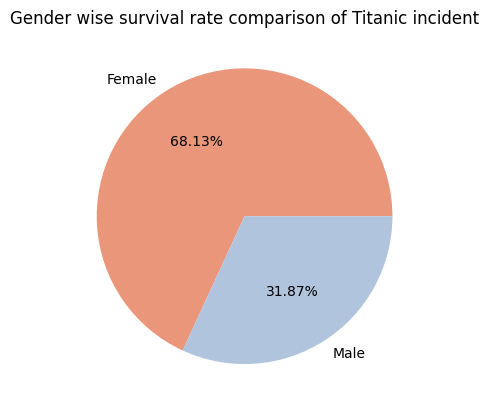

In [4]:
# Count survivors by gender
survived_gender_ration = titanic[titanic['Survived'] == 1]['Sex'].value_counts().sort_index()
total_survivor_count = sum(survived_gender_ration.values)

# Registered genders
registered_genders = [gender.capitalize() for gender in survived_gender_ration.keys().tolist()]

plt.pie(
    survived_gender_ration,
    labels = registered_genders,
    autopct="%0.2f%%",
    colors = ['#e9967a', '#b0c4de']
)
plt.title('Gender wise survival rate comparison of Titanic incident')
plt.show()

# 2. Count plot

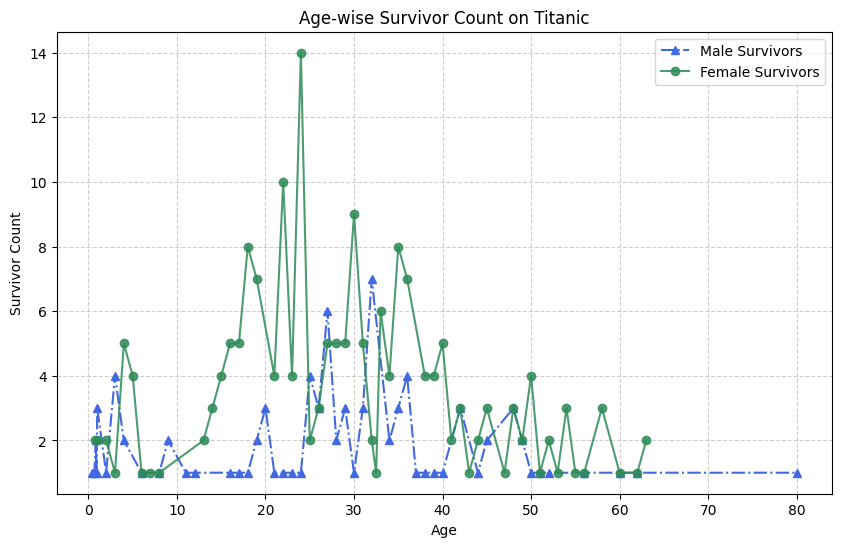

In [5]:
age_wise_male_survival = titanic[(titanic['Survived'] == 1) & (titanic['Sex'] == "male")]['Age'].value_counts().sort_index()
age_wise_female_survival = titanic[(titanic['Survived'] == 1) & (titanic['Sex'] == "female")]['Age'].value_counts().sort_index()

plt.figure(figsize=(10,6))  # larger, clearer plot

plt.plot(
    age_wise_male_survival.index,
    age_wise_male_survival.values,
    color="royalblue",
    linestyle="-.",
    marker="^",              # triangle marker
    label="Male Survivors"
)

plt.plot(
    age_wise_female_survival.index,
    age_wise_female_survival.values,
    color="seagreen",
    alpha=0.85,
    linestyle="-",
    marker="o",
    label="Female Survivors"
)

plt.xlabel("Age")
plt.ylabel("Survivor Count")
plt.title("Age-wise Survivor Count on Titanic")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)  # add subtle gridlines
plt.show()


# 3. Kde + Rug plot

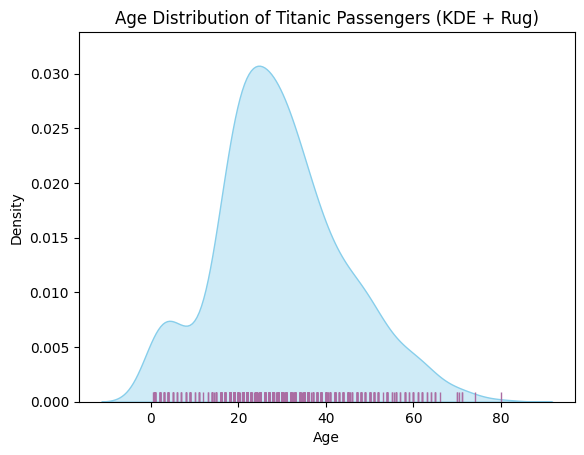

In [6]:
sns.kdeplot(data=titanic, x='Age', fill=True, color='skyblue', alpha=0.4)
sns.rugplot(data=titanic, x='Age', color='#aa6da3')

plt.title("Age Distribution of Titanic Passengers (KDE + Rug)")
plt.show()

# 4. Violin plot

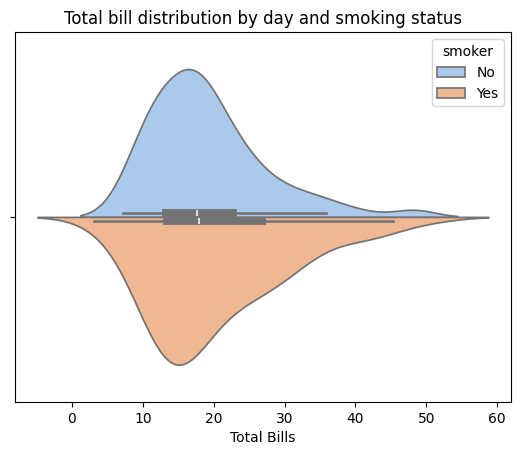

In [7]:
plt_obj = sns.violinplot(data=tips, x='total_bill', hue='smoker', split=True, palette='pastel', legend=True)

plt_obj.set_title('Total bill distribution by day and smoking status')
plt_obj.set_xlabel('Total Bills')

plt.show()

# 5. Box plot

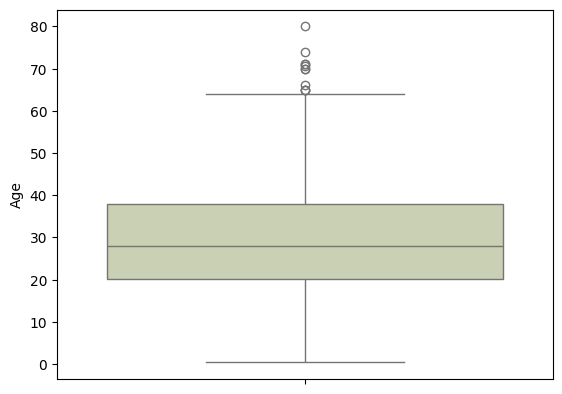

In [8]:
sns.boxplot(titanic['Age'], color='#ccd5ae')
plt.show()

# 6. Boxen plot

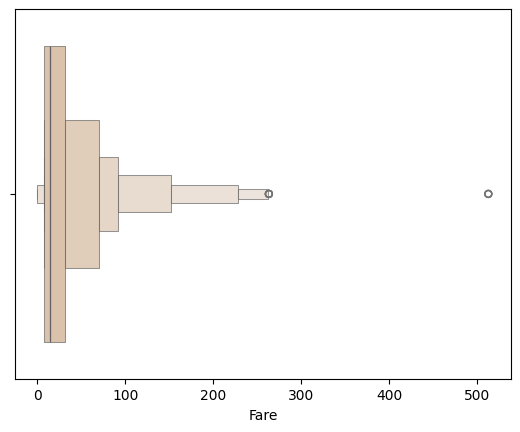

In [9]:
sns.boxenplot(titanic, x='Fare', color='#d4a373', alpha=0.65)
plt.show()

# 7. Histogram

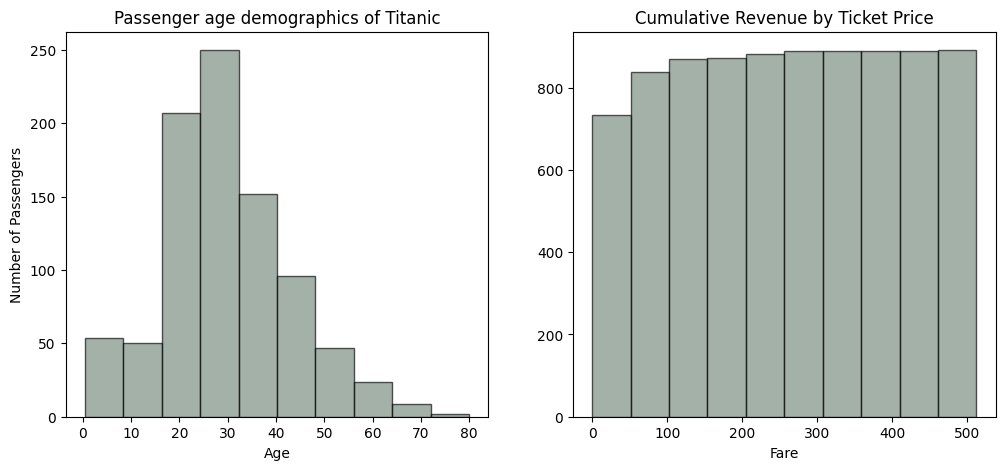

In [10]:
# Create a figure with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Get the Pclass and Age into a new DataFrame & Encode sex so we can use KNN for better imputation
my_df = titanic[['Pclass', 'Age', 'Fare']].copy()
my_df['Sex_Encoded'] = titanic['Sex'].map({'male': 1, 'female': 0})
imputer = KNNImputer(n_neighbors=5)
my_df['Age'] = imputer.fit_transform(my_df)[:, 1]

# Create the histogram at axis 0 index (Row 0, column 0)
axes[0].hist(my_df['Age'], color='#73877B', alpha=0.65, edgecolor='black')
axes[0].set_title("Passenger age demographics of Titanic")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Number of Passengers")

# Create the histogram at axis 0 index (Row 0, column 1)
axes[1].hist(my_df['Fare'], color='#73877B', alpha=0.65, edgecolor='black', cumulative=True)
axes[1].set_title("Cumulative Revenue by Ticket Price")
axes[1].set_xlabel("Fare")

# Render the image file
plt.show()

del my_df

# Bivariate Analysis

# 1. Scatter plot

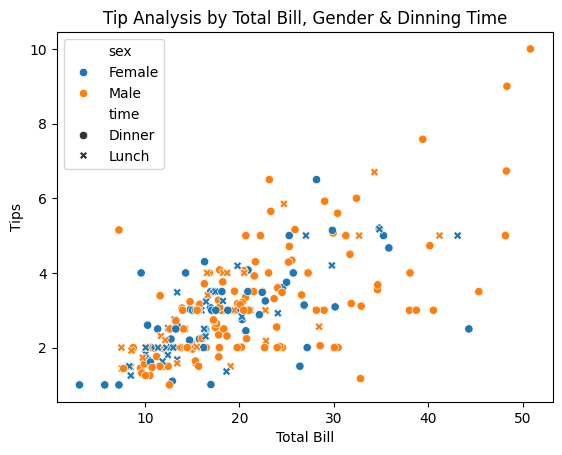

In [11]:
plt_obj = sns.scatterplot(tips, x='total_bill', y='tip', hue='sex', style='time')
plt_obj.set_xlabel("Total Bill")
plt_obj.set_ylabel("Tips")
plt_obj.set_title("Tip Analysis by Total Bill, Gender & Dinning Time")
plt.show()

# 2. Line plot

Null rate of total bills 0.00%. So, imputation or dropping is not necessary.
Removed 2 outliers from Sun
Removed 4 outliers from Sat
Removed 5 outliers from Thur
Removed 1 outliers from Fri


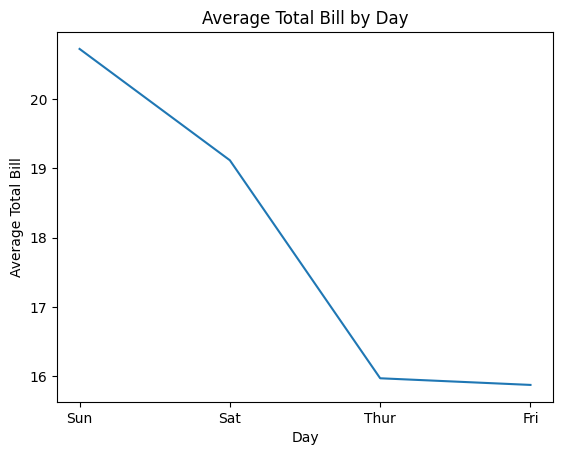

In [12]:
def tukeys_fences_outlier_removal(data_series):
    if not isinstance(data_series, pd.Series):
        raise TypeError("Input must be a pandas Series (single column).")
        
    if len(data_series.shape) != 1:
        raise ValueError("DataFrame must have exactly one column.")
        
    data_series = data_series.squeeze()
    
    q1 = data_series.quantile(0.25)
    q3 = data_series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return data_series[(data_series >= lower_bound) & (data_series <= upper_bound)]

# Analysis to find if imputation or dropping is necessary
bills_on_weekday = tips[['day', 'total_bill']].copy()
print(f"Null rate of total bills {bills_on_weekday['total_bill'].isnull().mean() * 100:.2f}%. So, imputation or dropping is not necessary.")

# Find the days to calculate averages
weekdays = bills_on_weekday['day'].unique()
day_wise_mean = []

for day in weekdays:
    day_bill_data = bills_on_weekday[bills_on_weekday['day'] == day]['total_bill']
    cleaned_data = tukeys_fences_outlier_removal(day_bill_data)
    
    print(f"Removed {len(day_bill_data) - len(cleaned_data)} outliers from {day}")
    
    mean_val = cleaned_data.mean()
    day_wise_mean.append(mean_val)

# Plot
plt_obj = sns.lineplot(x=weekdays, y=day_wise_mean)
plt_obj.set_title("Average Total Bill by Day")
plt_obj.set_xlabel("Day")
plt_obj.set_ylabel("Average Total Bill")
plt.show()

# 3. Joint plot

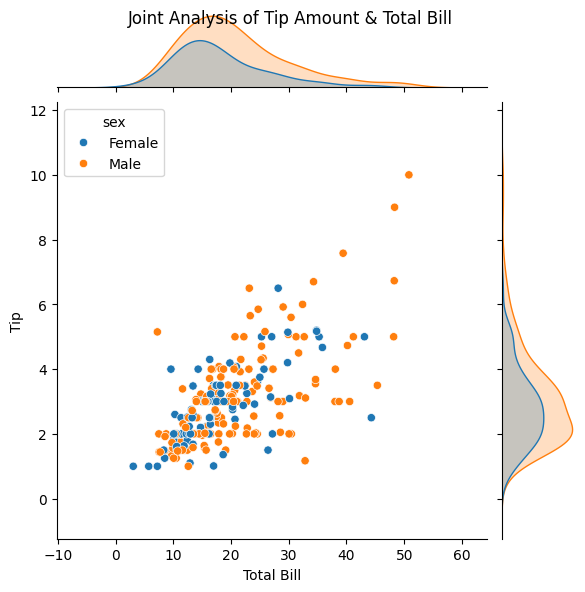

In [13]:
plt_obj = sns.jointplot(data=tips, x="total_bill", y="tip", kind="scatter", hue="sex")

plt_obj.fig.suptitle("Joint Analysis of Tip Amount & Total Bill")
plt_obj.ax_joint.set_xlabel("Total Bill")
plt_obj.ax_joint.set_ylabel("Tip")

plt.show()

# 4. Hexbin plot

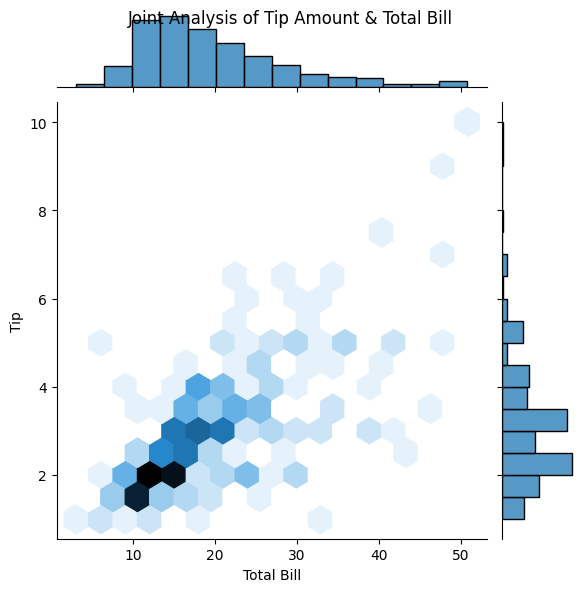

In [14]:
plt_obj = sns.jointplot(data=tips, x="total_bill", y="tip", kind="hex")

plt_obj.fig.suptitle("Joint Analysis of Tip Amount & Total Bill")
plt_obj.ax_joint.set_xlabel("Total Bill")
plt_obj.ax_joint.set_ylabel("Tip")

plt.show()

# 5. 2D kde plot

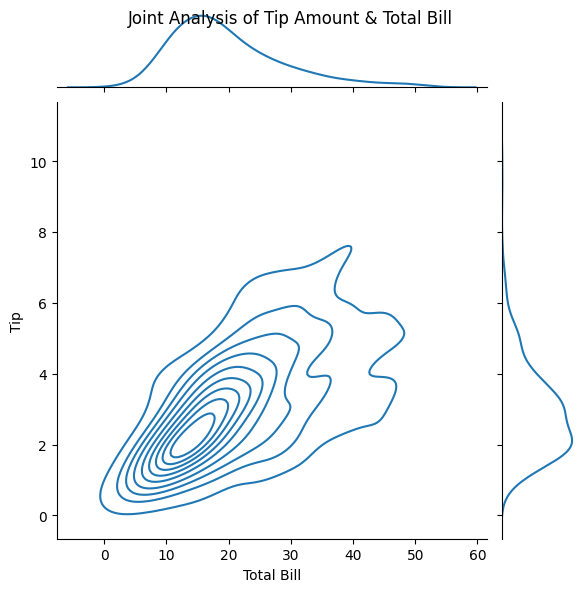

In [15]:
plt_obj = sns.jointplot(data=tips, x="total_bill", y="tip", kind="kde")

plt_obj.fig.suptitle("Joint Analysis of Tip Amount & Total Bill")
plt_obj.ax_joint.set_xlabel("Total Bill")
plt_obj.ax_joint.set_ylabel("Tip")

plt.show()

# 6. Box plot

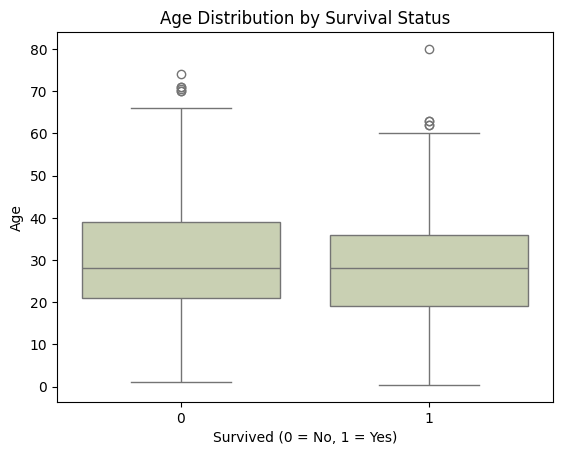

In [16]:
sns.boxplot(x="Survived", y="Age", data=titanic, color='#ccd5ae')

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

# 7. Violin plot

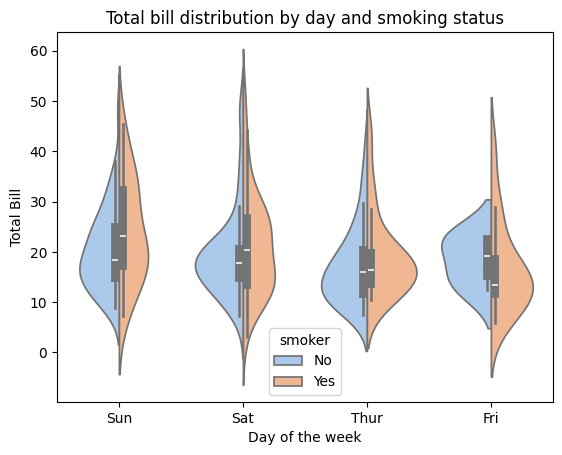

In [17]:
sns.violinplot(data=tips, x='day', y='total_bill', hue='smoker', split=True, palette='pastel', legend=True)

plt.title('Total bill distribution by day and smoking status')
plt.xlabel('Day of the week')
plt.ylabel('Total Bill')

plt.show()

# 8. Swarm plot

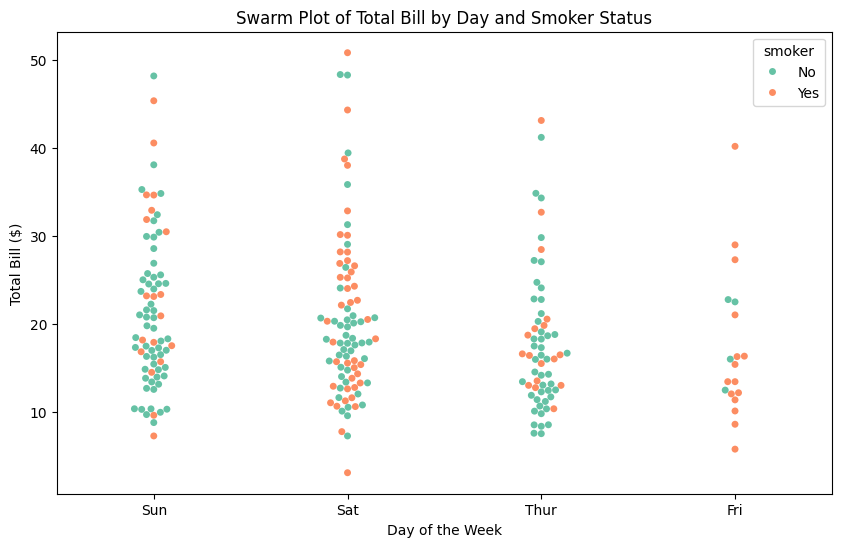

In [18]:
# Create the swarm plot
plt.figure(figsize=(10, 6))
plt_obj = sns.swarmplot(data=tips, x="day", y="total_bill", hue="smoker", palette="Set2")

# Add titles and labels
plt_obj.set_title("Swarm Plot of Total Bill by Day and Smoker Status")
plt_obj.set_xlabel("Day of the Week")
plt_obj.set_ylabel("Total Bill ($)")

# Display the plot
plt.show()

# 9. Count plot

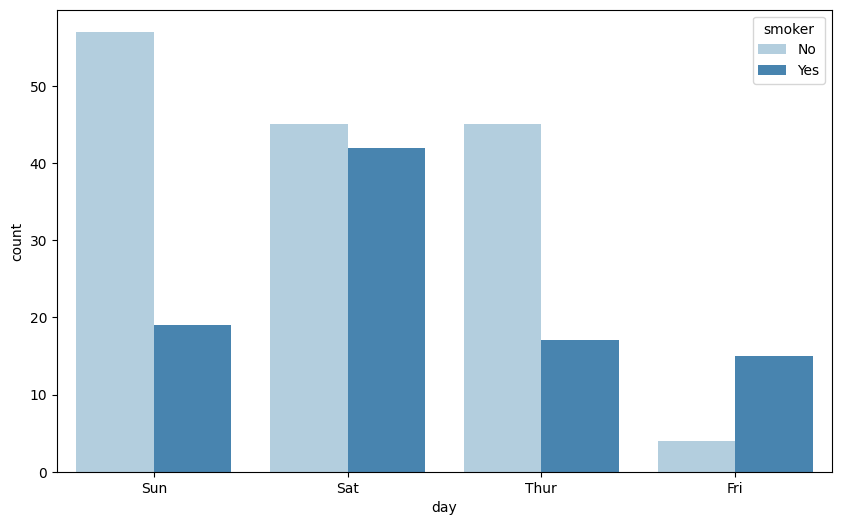

In [19]:
# Set up the plotting environment
plt.figure(figsize=(10, 6))

# Create the count plot for bivariate analysis
sns.countplot(
    data=tips,
    x="day",
    hue="smoker",
    palette="Blues"
)

# Add chart labels and title for clarity
plt_obj.set_title("Count of Transactions by Day and Smoker Status", fontsize=14, pad=15)
plt_obj.set_xlabel("Day of the Week", fontsize=12)
plt_obj.set_ylabel("Frequency (Count)", fontsize=12)

# Display the final plot
plt.show()

# Multivariate Analysis

# 1. Scatter plot

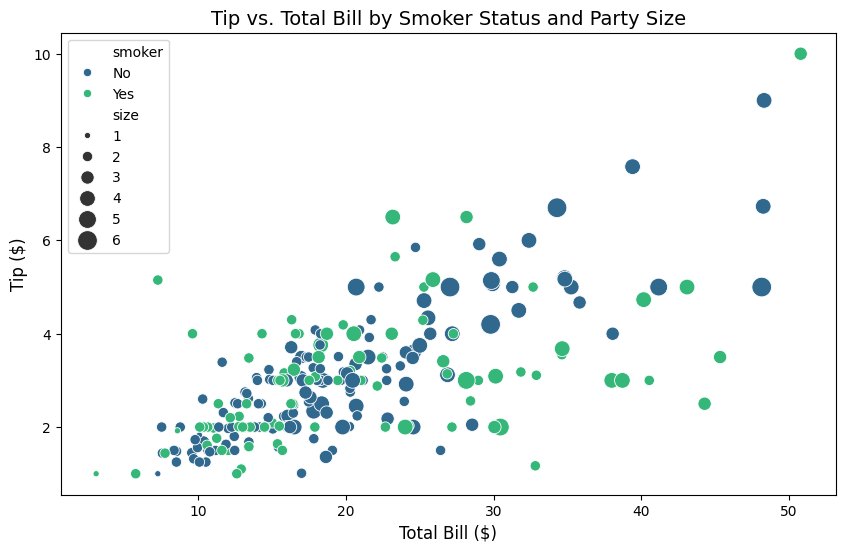

In [20]:
# Create the multivariate scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=tips,
    x="total_bill",
    y="tip",
    hue="smoker",
    size="size",
    sizes=(20, 200),
    palette="viridis",
)

# Add titles and labels
plt.title("Tip vs. Total Bill by Smoker Status and Party Size", fontsize=14)
plt.xlabel("Total Bill ($)", fontsize=12)
plt.ylabel("Tip ($)", fontsize=12)

# Display the plot
plt.show()

# 2. Pair plot

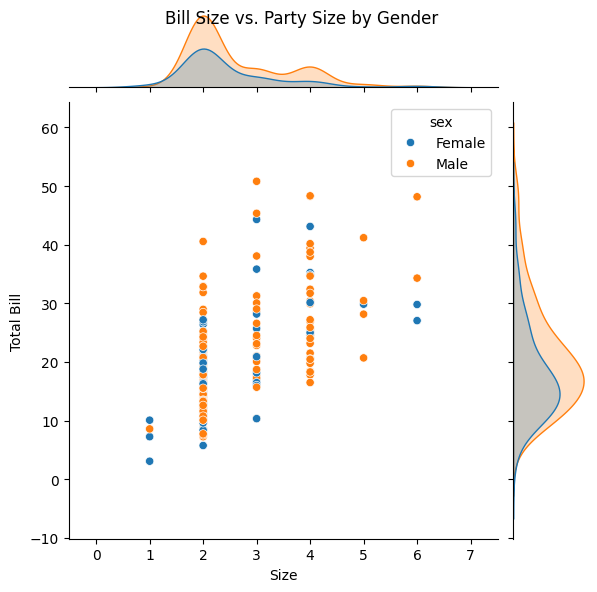

In [21]:
# Create a joint plot with regression line and KDE margins
plt_obj = sns.jointplot(data=tips, x="size", y="total_bill", hue="sex", kind="scatter")
plt_obj.fig.suptitle("Bill Size vs. Party Size by Gender")
plt_obj.set_axis_labels("Size", "Total Bill")

# Customize the display
plt.show()

# 3. Heatmap

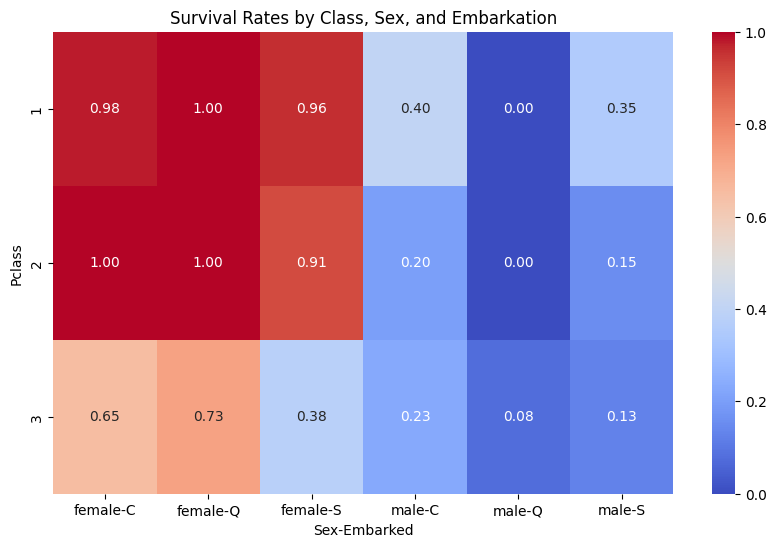

In [22]:
# Create a pivot table: survival rate by class and embarkation town, split by sex
pivot_table = titanic.pivot_table(
    values="Survived", 
    index="Pclass", 
    columns=["Sex", "Embarked"], 
    aggfunc="mean"
)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Survival Rates by Class, Sex, and Embarkation")
plt.show()

# 4. FacetGrid plot

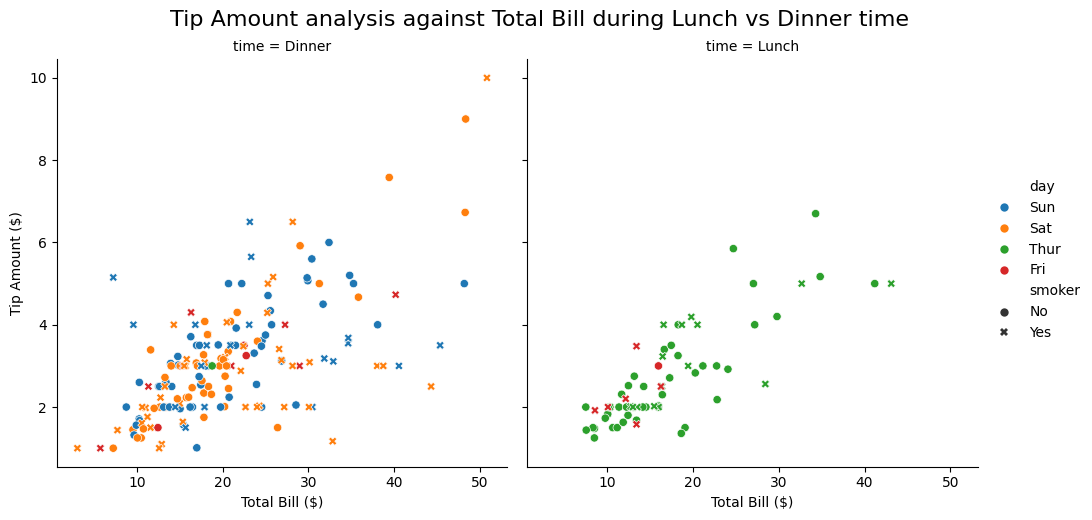

In [23]:
plt_obj = sns.relplot(
    data=tips,
    x="total_bill",
    y="tip",
    col="time",
    hue="day",
    style="smoker",
    kind="scatter",
)

# Set the x and y labels for the plots
plt_obj.set_axis_labels("Total Bill ($)", "Tip Amount ($)")

# Add a title above the entire figure
plt_obj.fig.suptitle("Tip Amount analysis against Total Bill during Lunch vs Dinner time", fontsize=16, y=1.03)

plt.show()

# 5. PairGrid

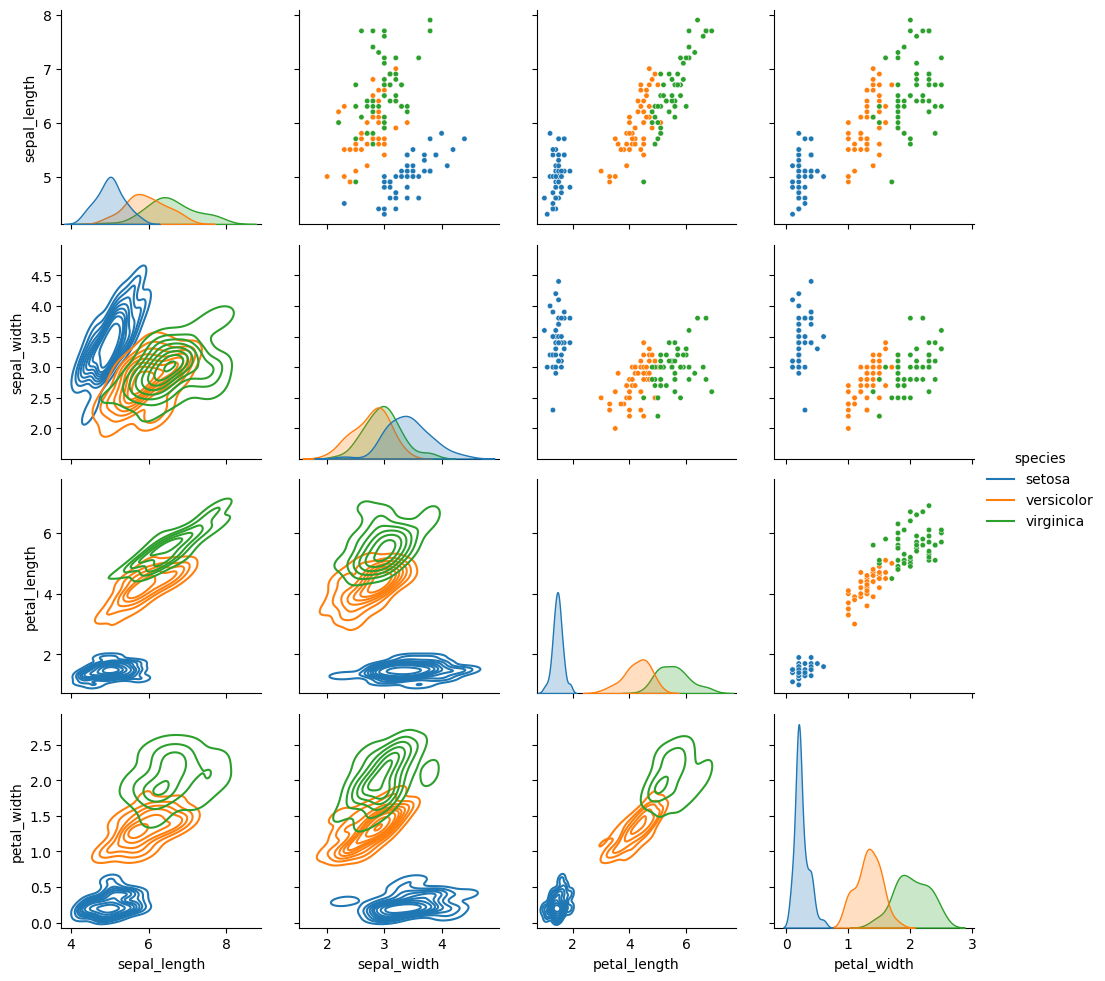

In [24]:
plt_obj = sns.PairGrid(iris, hue="species")

# Map the diagonal to a density plot
plt_obj.map_diag(sns.kdeplot, fill=True)

# Map the upper triangle to a scatter plot
plt_obj.map_upper(sns.scatterplot, s=15)

# Map the lower triangle to a bivariate density plot
plt_obj.map_lower(sns.kdeplot, fill=False)

# Add a legend
plt_obj.add_legend()

# Display the plot
plt.show()

# 6. Joint plot

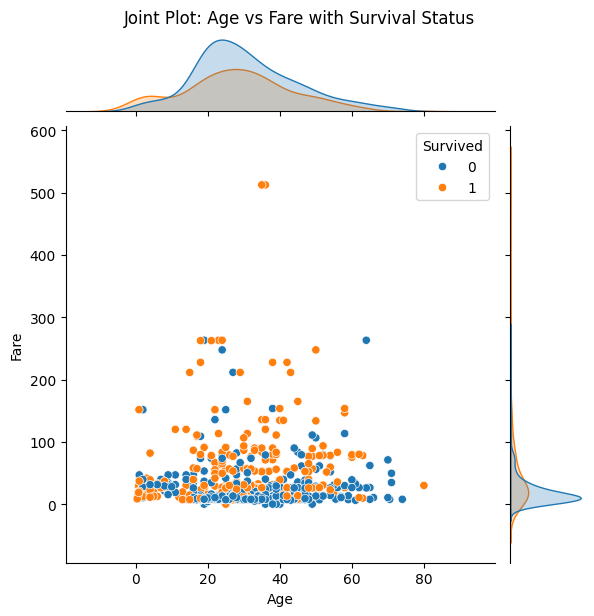

In [25]:
sns.jointplot(x="Age", y="Fare", data=titanic, kind="scatter", hue="Survived")

plt.suptitle("Joint Plot: Age vs Fare with Survival Status", y=1.02)
plt.show()

# 7. Boxen plot

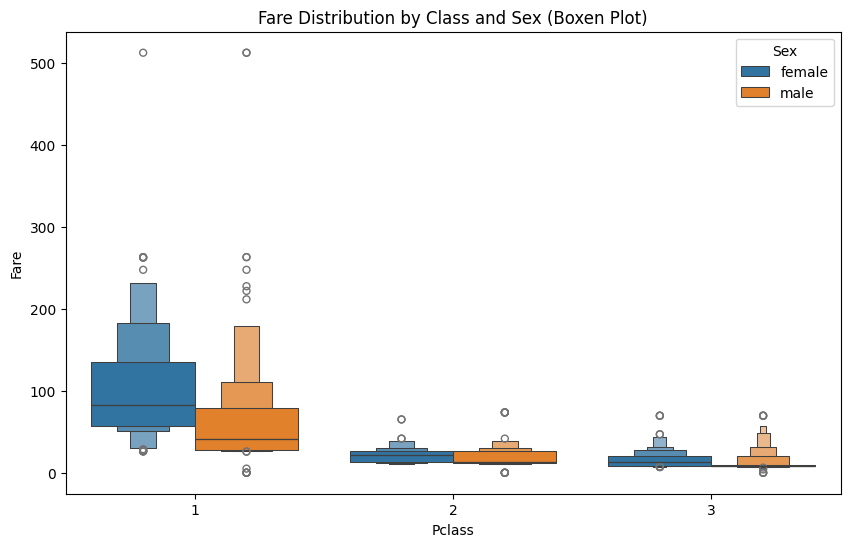

In [26]:
plt.figure(figsize=(10,6))
sns.boxenplot(x="Pclass", y="Fare", hue="Sex", data=titanic)
plt.title("Fare Distribution by Class and Sex (Boxen Plot)")
plt.show()